In [ ]:
# checking if the dataset was imported correctly
import os

for root, dirs, files in os.walk('/kaggle/input'):
    print(root)
    break
    
os.listdir('/kaggle/input')

os.listdir('/kaggle/input/flickr30k')

base_path = '/kaggle/input/flickr30k'

for item in os.listdir(base_path):
    print(item)

/kaggle/input
captions.txt
Images


# Part 1 : Feature Extraction Pipeline 
Since training a CNN alongside an RNN is computationally expensive, we will
"cache" the image features first. Use a pre-trained ResNet50 to convert each image into
a 2048-dimensional feature vector.

In [ ]:

"""
PART 1: FEATURE EXTRACTION PIPELINE 

In this step, we precompute and cache visual features for all images using a
pre-trained ResNet50 CNN. Instead of training a CNN and RNN together, which is
computationally expensive, we extract a fixed 2048-dimensional feature vector
for each image once and store it on disk.

These cached features will later be used as input to the Seq2Seq caption
generation model (Encoder-Decoder), significantly speeding up training.
"""

# -----------------------------
# IMPORTS 
# -----------------------------
import os                   # File system traversal and path handling
import pickle               # Saving extracted features as a serialized file
import torch                # Core PyTorch library
import torch.nn as nn       # Neural network layers and utilities
from torchvision import models, transforms  # Pretrained CNN + image transforms
from torch.utils.data import DataLoader, Dataset  # Dataset and batching
from PIL import Image       # Image loading and conversion
from tqdm import tqdm       # Progress bar for long loops

# -----------------------------
# Locate the image directory automatically
# -----------------------------
def find_image_dir():
    """
    Walks through /kaggle/input to find the directory
    that contains a large number of .jpg images.
    This avoids hardcoding dataset paths.
    """
    base_input = '/kaggle/input'
    for root, dirs, files in os.walk(base_input):
        if len([f for f in files if f.endswith('.jpg')]) > 1000:
            return root
    return None

IMAGE_DIR = find_image_dir()
OUTPUT_FILE = 'flickr30k_features.pkl'

if IMAGE_DIR:
    print(f"Found images at: {IMAGE_DIR}")
else:
    raise FileNotFoundError(
        "Could not find the Flickr30k image directory. "
        "Please ensure the dataset is added to the notebook."
    )

# -----------------------------
# Custom Dataset for Flickr30k images
# -----------------------------
class FlickrDataset(Dataset):
    """
    Loads images from disk and applies preprocessing.
    Returns:
    - transformed image tensor
    - image filename (used as key in feature dictionary)
    """
    def __init__(self, img_dir, transform):
        self.img_names = [
            f for f in os.listdir(img_dir)
            if f.endswith(('.jpg', '.jpeg'))
        ]
        self.transform = transform
        self.img_dir = img_dir

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, name)
        img = Image.open(img_path).convert('RGB')
        return self.transform(img), name

# -----------------------------
# Model setup and preprocessing
# -----------------------------
# Use GPU if available (T4 on Kaggle)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained ResNet50 (trained on ImageNet)
model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

# Remove the final classification layer
# Output becomes a 2048-dim feature vector per image
model = nn.Sequential(*list(model.children())[:-1])

# Enable multi-GPU (safe even if single GPU)
model = nn.DataParallel(model).to(device)

# Set model to evaluation mode (disables dropout, batchnorm updates)
model.eval()

# Image preprocessing required by ResNet
transform = transforms.Compose([
    transforms.Resize((224, 224)),          # ResNet input size
    transforms.ToTensor(),                  # Convert PIL image to tensor
    transforms.Normalize(                   # ImageNet normalization
        (0.485, 0.456, 0.406),
        (0.229, 0.224, 0.225)
    )
])

dataset = FlickrDataset(IMAGE_DIR, transform)

# DataLoader for efficient batch processing
loader = DataLoader(
    dataset,
    batch_size=128,
    num_workers=4
)

# -----------------------------
# Feature extraction loop
# -----------------------------
features_dict = {}

# Disable gradient computation to save memory and computation
with torch.no_grad():
    for imgs, names in tqdm(loader, desc="Extracting Features"):
        imgs = imgs.to(device)

        # Forward pass through ResNet
        # Output shape: (batch_size, 2048, 1, 1)
        feats = model(imgs).view(imgs.size(0), -1)  # Flatten to (batch_size, 2048)

        # Store each image's feature vector using filename as key
        for i, name in enumerate(names):
            features_dict[name] = feats[i].cpu().numpy()

# Save all extracted features to disk
with open(OUTPUT_FILE, 'wb') as f:
    pickle.dump(features_dict, f)

print(
    f"Success! {len(features_dict)} images processed "
    f"and saved to {OUTPUT_FILE}"
)






Found images at: /kaggle/input/flickr30k/Images


Extracting Features: 100%|██████████| 249/249 [01:26<00:00,  2.87it/s]


Success! 31783 images processed and saved to flickr30k_features.pkl


# Part 2:Vocabulary & Text Pre-Processing
Load the captions.txt file from dataset and preprocess the data.

In [ ]:
"""
PART 2: VOCABULARY & TEXT PREPROCESSING

This step processes the raw captions from Flickr30k by:
1. Cleaning and normalizing text
2. Adding special tokens (<start>, <end>, <pad>, <unk>)
3. Building a vocabulary with word-to-index mappings
4. Converting captions into numerical sequences

These processed captions will be used as input/output sequences for the Seq2Seq decoder during training.
"""

# -----------------------------
# IMPORTS
# -----------------------------
import os                       # File path handling
import string                   # Removing punctuation
from collections import Counter # Word frequency counting
import csv                      # To read CSV correctly
import torch                    # Tensor operations
import pickle                   # To save vocab and sequences

# -----------------------------
# Load captions.txt
# -----------------------------
CAPTION_FILE = None

for root, dirs, files in os.walk('/kaggle/input'):
    if 'captions.txt' in files:
        CAPTION_FILE = os.path.join(root, 'captions.txt')
        break

if CAPTION_FILE is None:
    raise FileNotFoundError("captions.txt not found in dataset")

print(f"Found captions file at: {CAPTION_FILE}")

# -----------------------------
# Read and parse captions 
# -----------------------------
captions_dict = {}

with open(CAPTION_FILE, 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    next(reader)  # Skip header line if present: "image,caption"
    for row in reader:
        if len(row) < 2:
            continue
        image_name = row[0].strip()
        caption = row[1].strip()

        if image_name not in captions_dict:
            captions_dict[image_name] = []
        captions_dict[image_name].append(caption)

print(f"Total images with captions: {len(captions_dict)}")

# -----------------------------
# Text cleaning function
# -----------------------------
def clean_caption(caption):
    """
    Lowercase, remove punctuation, remove extra spaces
    """
    caption = caption.lower()
    caption = caption.translate(str.maketrans('', '', string.punctuation))
    caption = caption.strip()
    return caption

# -----------------------------
# Clean captions and add tokens
# -----------------------------
all_captions = []

for image in captions_dict:
    cleaned_list = []
    for cap in captions_dict[image]:
        cleaned = clean_caption(cap)
        cleaned = "<start> " + cleaned + " <end>"
        cleaned_list.append(cleaned)
        all_captions.append(cleaned)
    captions_dict[image] = cleaned_list

# -----------------------------
# Build vocabulary
# -----------------------------

word_counts = Counter()

for caption in all_captions:
    word_counts.update(caption.split())

MIN_FREQ = 5  # Minimum frequency to include a word

# Remove special tokens from word_counts before building vocab
special_tokens = ["<pad>", "<start>", "<end>", "<unk>"]
for token in special_tokens:
    if token in word_counts:
        del word_counts[token]

# Build vocab from words meeting frequency threshold
vocab = [word for word, freq in word_counts.items() if freq >= MIN_FREQ]

# Add special tokens at the beginning
vocab = special_tokens + vocab

word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

pad_idx = word2idx["<pad>"]
unk_idx = word2idx["<unk>"]

print(f"Vocabulary size: {len(vocab)}")
print(f"Vocab contains {len(word2idx)} unique words")
print(f"Special tokens: <pad>={pad_idx}, <unk>={unk_idx}, <start>={word2idx['<start>']}, <end>={word2idx['<end>']}")

# -----------------------------
# Convert captions to sequences
# -----------------------------
def caption_to_sequence(caption):
    return [word2idx.get(word, unk_idx) for word in caption.split()]

caption_sequences = {}

for image, caps in captions_dict.items():
    caption_sequences[image] = [caption_to_sequence(cap) for cap in caps]

# -----------------------------
# Find maximum caption length
# -----------------------------
max_len = max(len(seq) for caps in caption_sequences.values() for seq in caps)
print(f"Maximum caption length: {max_len}")

# -----------------------------
# Save vocabulary and captions for future use
# -----------------------------
VOCAB_FILE = "flickr30k_vocab.pkl"
CAPTIONS_FILE = "flickr30k_captions.pkl"

with open(VOCAB_FILE, "wb") as f:
    pickle.dump({
        "word2idx": word2idx,
        "idx2word": idx2word,
        "pad_idx": pad_idx,
        "unk_idx": unk_idx,
        "max_len": max_len
    }, f)

with open(CAPTIONS_FILE, "wb") as f:
    pickle.dump(caption_sequences, f)

print("Vocabulary and caption sequences saved successfully.")


Found captions file at: /kaggle/input/flickr30k/captions.txt
Total images with captions: 31783
Vocabulary size: 7727
Vocab contains 7727 unique words
Special tokens: <pad>=0, <unk>=3, <start>=1, <end>=2
Maximum caption length: 80
Vocabulary and caption sequences saved successfully.


# Part 3: The Seq2Seq Architecture

Build the following two components using PyTorch:

- **Encoder**: A linear layer that projects the 2048-dimensional cached feature vector into a hidden representation of size `hidden_size` (e.g., 512).

- **Decoder**: An LSTM or GRU network with the following properties:
  -  **Input**: Word embeddings of the caption.
  -  **Initial Hidden State**: The output of the Encoder.
  -  **Output**: A linear layer that maps the decoder outputs to `vocab_size`.


In [ ]:
import torch
import torch.nn as nn

# -----------------------------
# PARAMETERS
# -----------------------------
EMBED_SIZE = 256      # Size of word embeddings
HIDDEN_SIZE = 512     # Hidden size for LSTM
NUM_LAYERS = 1        # LSTM layers
VOCAB_SIZE = len(word2idx)  # Vocabulary size from Part 2
DROPOUT = 0.5

# -----------------------------
# ENCODER
# -----------------------------
class Encoder(nn.Module):
    """
    Encoder: Projects precomputed 2048-dim image feature vector
    into a hidden state vector suitable for initializing the Decoder.
    """
    def __init__(self, feature_size=2048, hidden_size=HIDDEN_SIZE):
        super(Encoder, self).__init__()
        self.fc = nn.Linear(feature_size, hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, features):
        """
        features: [batch_size, 2048]
        returns: [batch_size, hidden_size]
        """
        out = self.fc(features)
        out = self.relu(out)
        out = self.dropout(out)
        return out

# -----------------------------
# DECODER
# -----------------------------
class Decoder(nn.Module):
    """
    Decoder: LSTM that generates captions word by word.
    - Input: Word embeddings of captions
    - Hidden state: Initialized from Encoder output
    - Output: Linear layer to vocab logits
    """
    def __init__(self, embed_size=EMBED_SIZE, hidden_size=HIDDEN_SIZE,
                 vocab_size=VOCAB_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT):
        super(Decoder, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        # Note: dropout param only applies between LSTM layers, so set to 0 when num_layers=1
        lstm_dropout = dropout if num_layers > 1 else 0
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True, dropout=lstm_dropout)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, captions, hidden, cell):
        """
        captions: [batch_size, seq_len] (token indices)
        hidden: [num_layers, batch_size, hidden_size]
        cell: [num_layers, batch_size, hidden_size]
        returns: logits for each word in sequence
        """
        embeddings = self.embed(captions)      # [batch_size, seq_len, embed_size]
        embeddings = self.dropout(embeddings)
        outputs, (hidden, cell) = self.lstm(embeddings, (hidden, cell))
        logits = self.fc(outputs)              # [batch_size, seq_len, vocab_size]
        return logits, hidden, cell

    def init_hidden_state(self, encoder_out):
        """
        Initialize hidden and cell states of LSTM from encoder output.
        encoder_out: [batch_size, hidden_size]
        returns: (hidden, cell) each [num_layers, batch_size, hidden_size]
        """
        # Expand to num_layers dimension
        hidden = encoder_out.unsqueeze(0).repeat(NUM_LAYERS, 1, 1)
        cell = torch.zeros_like(hidden)  # Initialize cell state as zeros
        return hidden, cell

# Part 4: Training & Inference

- **Loss Function**  
  -  Use CrossEntropy Loss.
  -  Ensure `ignore_index` is set to the padding token ID.

- **Optimization**  
  -  Use the Adam optimizer.

- **Inference Function**  
  -  Implement **Greedy Search** to generate words sequentially from an image feature.
  -  Implement **Beam Search** to generate words sequentially until the `<end>` token is reached.


In [ ]:
# -----------------------------
# DATA VALIDATION
# -----------------------------
print("Validating caption sequences...")
max_idx_found = 0
for img_name, captions_list in caption_sequences.items():
    for caption in captions_list:
        max_idx_found = max(max_idx_found, max(caption))
        # Check for out-of-bounds indices
        if max(caption) >= VOCAB_SIZE:
            print(f"ERROR: Found token index {max(caption)} >= VOCAB_SIZE {VOCAB_SIZE}")
            print(f"Caption: {caption}")
            break

print(f"Max token index in data: {max_idx_found}")
print(f"VOCAB_SIZE: {VOCAB_SIZE}")
assert max_idx_found < VOCAB_SIZE, f"Token indices must be < VOCAB_SIZE"

Validating caption sequences...
Max token index in data: 7726
VOCAB_SIZE: 7727


Total images: 31783
Training images: 28604
Validation images: 3179


Epoch 1/25 [Train]: 100%|██████████| 447/447 [00:12<00:00, 34.98it/s]


Epoch [1/25] Train Loss: 4.9869 | Val Loss: 4.3356


Epoch 2/25 [Train]: 100%|██████████| 447/447 [00:12<00:00, 34.62it/s]


Epoch [2/25] Train Loss: 4.2372 | Val Loss: 4.0428


...

Epoch [23/25] Train Loss: 2.9816 | Val Loss: 3.0750


Epoch 24/25 [Train]: 100%|██████████| 447/447 [00:12<00:00, 35.48it/s]


Epoch [24/25] Train Loss: 2.9503 | Val Loss: 3.0476


Epoch 25/25 [Train]: 100%|██████████| 447/447 [00:12<00:00, 34.86it/s]


Epoch [25/25] Train Loss: 2.9497 | Val Loss: 3.0456


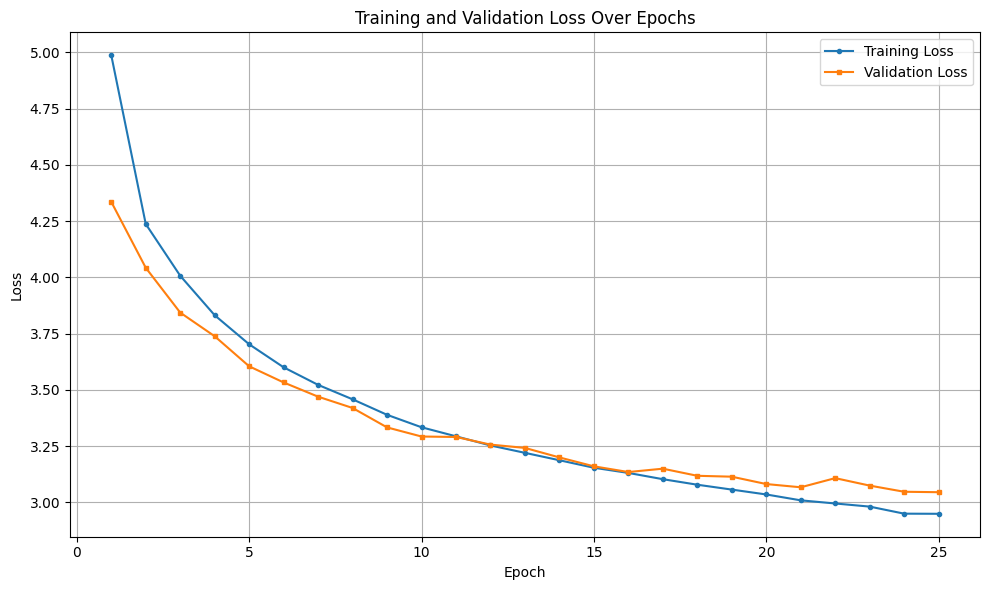

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import random as py_random

# -----------------------------
# PARAMETERS
# -----------------------------
BATCH_SIZE = 64
NUM_EPOCHS = 25
LEARNING_RATE = 3e-4
MAX_SEQ_LEN = max_len          # from Part 2
PAD_IDX = pad_idx
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# CUSTOM DATASET
# -----------------------------
class CaptionDataset(Dataset):
    def __init__(self, features_dict, caption_sequences, image_names=None):
        self.features_dict = features_dict
        self.caption_sequences = caption_sequences
        self.image_names = image_names if image_names else list(features_dict.keys())

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        feature = torch.tensor(self.features_dict[img_name], dtype=torch.float32)
        # pick one random caption per image
        captions = self.caption_sequences[img_name]
        caption = torch.tensor(captions[np.random.randint(len(captions))], dtype=torch.long)
        return feature, caption

# Collate function for padding
def collate_fn(batch):
    features, captions = zip(*batch)
    features = torch.stack(features, 0)
    lengths = [len(cap) for cap in captions]
    max_len_batch = max(lengths)
    padded_captions = torch.full((len(captions), max_len_batch), PAD_IDX, dtype=torch.long)
    for i, cap in enumerate(captions):
        padded_captions[i, :len(cap)] = cap
    return features, padded_captions, lengths

# -----------------------------
# LOAD DATASET
# -----------------------------
with open("flickr30k_features.pkl", "rb") as f:
    features_dict = pickle.load(f)

with open("flickr30k_captions.pkl", "rb") as f:
    caption_sequences = pickle.load(f)

# -----------------------------
# TRAIN / VALIDATION SPLIT (90/10)
# -----------------------------
all_image_names = list(features_dict.keys())
py_random.seed(42)
py_random.shuffle(all_image_names)

split_idx = int(0.9 * len(all_image_names))
train_names = all_image_names[:split_idx]
val_names = all_image_names[split_idx:]

print(f"Total images: {len(all_image_names)}")
print(f"Training images: {len(train_names)}")
print(f"Validation images: {len(val_names)}")

train_dataset = CaptionDataset(features_dict, caption_sequences, train_names)
val_dataset = CaptionDataset(features_dict, caption_sequences, val_names)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# -----------------------------
# LOSS & OPTIMIZER
# -----------------------------
encoder = Encoder().to(DEVICE)
decoder = Decoder().to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
params = list(encoder.parameters()) + list(decoder.parameters())
optimizer = optim.Adam(params, lr=LEARNING_RATE)

# -----------------------------
# TRAINING LOOP WITH VALIDATION
# -----------------------------
train_loss_history = []
val_loss_history = []

for epoch in range(NUM_EPOCHS):
    # --- Training ---
    encoder.train()
    decoder.train()
    running_loss = 0

    for features, captions, lengths in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]"):
        features = features.to(DEVICE)
        captions = captions.to(DEVICE)

        encoder_out = encoder(features)
        hidden, cell = decoder.init_hidden_state(encoder_out)

        inputs = captions[:, :-1]
        targets = captions[:, 1:]

        logits, _, _ = decoder(inputs, hidden, cell)

        seq_len = min(logits.shape[1], targets.shape[1])
        logits = logits[:, :seq_len, :].reshape(-1, VOCAB_SIZE)
        targets = targets[:, :seq_len].reshape(-1)

        loss = criterion(logits, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    # --- Validation ---
    encoder.eval()
    decoder.eval()
    val_running_loss = 0

    with torch.no_grad():
        for features, captions, lengths in val_loader:
            features = features.to(DEVICE)
            captions = captions.to(DEVICE)

            encoder_out = encoder(features)
            hidden, cell = decoder.init_hidden_state(encoder_out)

            inputs = captions[:, :-1]
            targets = captions[:, 1:]

            logits, _, _ = decoder(inputs, hidden, cell)

            seq_len = min(logits.shape[1], targets.shape[1])
            logits = logits[:, :seq_len, :].reshape(-1, VOCAB_SIZE)
            targets = targets[:, :seq_len].reshape(-1)

            loss = criterion(logits, targets)
            val_running_loss += loss.item()

    avg_val_loss = val_running_loss / len(val_loader)
    val_loss_history.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

# -----------------------------
# PLOT TRAINING & VALIDATION LOSS
# -----------------------------
plt.figure(figsize=(10, 6))
plt.plot(range(1, NUM_EPOCHS+1), train_loss_history, label="Training Loss", marker='o', markersize=3)
plt.plot(range(1, NUM_EPOCHS+1), val_loss_history, label="Validation Loss", marker='s', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# INFERENCE FUNCTIONS
# -----------------------------

def greedy_search(image_feature, max_len=MAX_SEQ_LEN):
    """
    Generates a caption using greedy search:
    Always pick the word with highest probability at each step.
    """
    encoder.eval()
    decoder.eval()
    feature = torch.tensor(image_feature, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        encoder_out = encoder(feature)
        hidden, cell = decoder.init_hidden_state(encoder_out)

        caption = [word2idx["<start>"]]
        for _ in range(max_len):
            input_tensor = torch.tensor([caption[-1]], dtype=torch.long).unsqueeze(0).to(DEVICE)
            logits, hidden, cell = decoder(input_tensor, hidden, cell)
            next_word = logits.argmax(2).item()
            if next_word == word2idx["<end>"]:
                break
            caption.append(next_word)
    return [idx2word[idx] for idx in caption[1:]]

def beam_search(image_feature, beam_width=5, max_len=MAX_SEQ_LEN):
    """
    Generates a caption using beam search.
    Keeps top 'beam_width' sequences at each step.
    Uses length-normalized scoring to avoid bias toward short captions.
    """
    encoder.eval()
    decoder.eval()
    feature = torch.tensor(image_feature, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        encoder_out = encoder(feature)
        hidden, cell = decoder.init_hidden_state(encoder_out)

        # Each beam is (sequence, log_prob, hidden, cell)
        beams = [([word2idx["<start>"]], 0.0, hidden, cell)]

        completed = []

        for _ in range(max_len):
            candidates = []
            for seq, score, h, c in beams:
                # If sequence already ended, move to completed
                if seq[-1] == word2idx["<end>"]:
                    completed.append((seq, score, h, c))
                    continue
                
                input_tensor = torch.tensor([seq[-1]], dtype=torch.long).unsqueeze(0).to(DEVICE)
                logits, h_new, c_new = decoder(input_tensor, h, c)
                probs = torch.log_softmax(logits.squeeze(1), dim=-1)  # [1, vocab_size]
                topk_probs, topk_idx = probs.topk(beam_width, dim=-1)  # [1, beam_width]

                topk_probs = topk_probs.squeeze(0)  # [beam_width]
                topk_idx = topk_idx.squeeze(0)      # [beam_width]

                for k in range(beam_width):
                    next_word = topk_idx[k].item()
                    next_score = score + topk_probs[k].item()
                    candidates.append((seq + [next_word], next_score, h_new, c_new))

            if not candidates:
                break

            # Keep top beam_width sequences (use length-normalized scores for ranking)
            candidates.sort(key=lambda x: x[1] / len(x[0]), reverse=True)
            beams = candidates[:beam_width]
            
            # Early stopping if all beams have ended
            if all(beam[0][-1] == word2idx["<end>"] for beam in beams):
                completed.extend(beams)
                break

        # Add any remaining beams
        completed.extend(beams)

        # Pick best completed sequence using length-normalized score
        completed.sort(key=lambda x: x[1] / len(x[0]), reverse=True)
        best_seq = completed[0][0]

        # Remove <start> and <end> tokens
        result = [idx2word[idx] for idx in best_seq if idx not in (word2idx["<start>"], word2idx["<end>"])]
        return result

# Quantative Evaluation

In [ ]:
import numpy as np
from collections import Counter
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
import nltk

# Download required NLTK data
try:
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
except:
    pass

# -----------------------------
# GENERATE PREDICTIONS FOR TEST SET
# -----------------------------
def generate_predictions(features_dict, caption_sequences, image_names=None, num_samples=1000, use_beam=True):
    """
    Generate captions for a subset of images.
    If image_names is provided, use those; otherwise use first num_samples from features_dict.
    """
    encoder.eval()
    decoder.eval()
    
    if image_names is None:
        image_names = list(features_dict.keys())[:num_samples]
    else:
        image_names = image_names[:num_samples]
    
    predictions = {}
    references = {}
    
    print(f"Generating captions for {len(image_names)} images...")
    
    for img_name in tqdm(image_names, desc="Generating captions"):
        if img_name not in features_dict:
            continue
        feature = features_dict[img_name]
        
        # Generate caption
        if use_beam:
            pred_caption = beam_search(feature, beam_width=5)
        else:
            pred_caption = greedy_search(feature)
        
        # Get reference captions (ground truth)
        ref_captions = []
        for cap_idx in caption_sequences[img_name]:
            cap_words = [idx2word[idx] for idx in cap_idx 
                        if idx not in (word2idx["<start>"], word2idx["<end>"], word2idx["<pad>"])]
            ref_captions.append(cap_words)
        
        predictions[img_name] = pred_caption
        references[img_name] = ref_captions
    
    return predictions, references

# -----------------------------
# BLEU SCORE CALCULATION
# -----------------------------
def calculate_bleu(predictions, references):
    """
    Calculate BLEU-1, BLEU-2, BLEU-3, BLEU-4 scores
    """
    smoothing = SmoothingFunction().method1
    
    bleu_1_scores = []
    bleu_2_scores = []
    bleu_3_scores = []
    bleu_4_scores = []
    
    for img_name in predictions:
        pred = predictions[img_name]
        refs = references[img_name]
        
        bleu_1 = sentence_bleu(refs, pred, weights=(1, 0, 0, 0), smoothing_function=smoothing)
        bleu_1_scores.append(bleu_1)
        
        bleu_2 = sentence_bleu(refs, pred, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothing)
        bleu_2_scores.append(bleu_2)
        
        bleu_3 = sentence_bleu(refs, pred, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smoothing)
        bleu_3_scores.append(bleu_3)
        
        bleu_4 = sentence_bleu(refs, pred, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothing)
        bleu_4_scores.append(bleu_4)
    
    return {
        'BLEU-1': np.mean(bleu_1_scores),
        'BLEU-2': np.mean(bleu_2_scores),
        'BLEU-3': np.mean(bleu_3_scores),
        'BLEU-4': np.mean(bleu_4_scores)
    }

# -----------------------------
# PRECISION, RECALL, F1 SCORE
# -----------------------------
def calculate_precision_recall_f1(predictions, references, ngram=1):
    """
    Calculate n-gram level Precision, Recall, F1.
    Recall is computed against the best-matching single reference
    (not the union of all references), which gives a fairer score.
    """
    def get_ngrams(tokens, n):
        """Extract n-grams from token list"""
        if n == 1:
            return Counter(tokens)
        ngrams = []
        for i in range(len(tokens) - n + 1):
            ngrams.append(tuple(tokens[i:i+n]))
        return Counter(ngrams)
    
    precisions = []
    recalls = []
    f1_scores = []
    
    for img_name in predictions:
        pred = predictions[img_name]
        refs = references[img_name]
        
        pred_ngrams = get_ngrams(pred, ngram)
        pred_total = sum(pred_ngrams.values())
        
        # Compute against the best-matching single reference
        best_precision = 0
        best_recall = 0
        best_f1 = 0
        
        for ref in refs:
            ref_ngrams = get_ngrams(ref, ngram)
            ref_total = sum(ref_ngrams.values())
            
            matches = sum((pred_ngrams & ref_ngrams).values())
            
            precision = matches / pred_total if pred_total > 0 else 0
            recall = matches / ref_total if ref_total > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            
            if f1 > best_f1:
                best_precision = precision
                best_recall = recall
                best_f1 = f1
        
        precisions.append(best_precision)
        recalls.append(best_recall)
        f1_scores.append(best_f1)
    
    return {
        f'{ngram}-gram Precision': np.mean(precisions),
        f'{ngram}-gram Recall': np.mean(recalls),
        f'{ngram}-gram F1': np.mean(f1_scores)
    }

# -----------------------------
# METEOR SCORE
# -----------------------------
def calculate_meteor(predictions, references):
    """
    Calculate METEOR score (requires nltk wordnet).
    meteor_score expects: references as list of str, hypothesis as str.
    """
    meteor_scores_list = []
    
    for img_name in predictions:
        pred = ' '.join(predictions[img_name])
        refs = [' '.join(ref) for ref in references[img_name]]
        
        try:
            # meteor_score(references, hypothesis) — refs is list of strings, pred is a string
            score = meteor_score(refs, pred)
            meteor_scores_list.append(score)
        except Exception:
            continue
    
    return {'METEOR': np.mean(meteor_scores_list) if meteor_scores_list else 0}

# -----------------------------
# ROUGE SCORE
# -----------------------------
def calculate_rouge(predictions, references):
    """
    Calculate ROUGE-L score
    """
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    rouge_scores_list = []
    
    for img_name in predictions:
        pred = ' '.join(predictions[img_name])
        
        # Calculate ROUGE against all references and take max
        scores = []
        for ref in references[img_name]:
            ref_text = ' '.join(ref)
            score = scorer.score(ref_text, pred)
            scores.append(score['rougeL'].fmeasure)
        
        rouge_scores_list.append(max(scores))
    
    return {'ROUGE-L': np.mean(rouge_scores_list)}

# -----------------------------
# RUN COMPLETE EVALUATION
# -----------------------------
print("="*60)
print("QUANTITATIVE EVALUATION")
print("="*60)

# Use validation set images for evaluation
predictions, references = generate_predictions(
    features_dict, 
    caption_sequences, 
    image_names=val_names,
    num_samples=1000,
    use_beam=True
)

# Print average predicted caption length
avg_pred_len = np.mean([len(p) for p in predictions.values()])
avg_ref_len = np.mean([np.mean([len(r) for r in refs]) for refs in references.values()])
print(f"\nAvg predicted caption length: {avg_pred_len:.1f} words")
print(f"Avg reference caption length: {avg_ref_len:.1f} words")

print("\n" + "="*60)
print("EVALUATION METRICS")
print("="*60)

# BLEU Scores
bleu_scores = calculate_bleu(predictions, references)
print("\n--- BLEU Scores ---")
for metric, score in bleu_scores.items():
    print(f"{metric}: {score:.4f}")

# Precision, Recall, F1 (Unigrams)
prf_unigram = calculate_precision_recall_f1(predictions, references, ngram=1)
print("\n--- Token-level Metrics (Unigrams) ---")
for metric, score in prf_unigram.items():
    print(f"{metric}: {score:.4f}")

# Precision, Recall, F1 (Bigrams)
prf_bigram = calculate_precision_recall_f1(predictions, references, ngram=2)
print("\n--- Bigram Metrics ---")
for metric, score in prf_bigram.items():
    print(f"{metric}: {score:.4f}")

# Precision, Recall, F1 (Trigrams)
prf_trigram = calculate_precision_recall_f1(predictions, references, ngram=3)
print("\n--- Trigram Metrics ---")
for metric, score in prf_trigram.items():
    print(f"{metric}: {score:.4f}")

# METEOR Score
try:
    meteor_result = calculate_meteor(predictions, references)
    print("\n--- METEOR Score ---")
    for metric, score in meteor_result.items():
        print(f"{metric}: {score:.4f}")
except Exception as e:
    meteor_result = {}
    print(f"\n--- METEOR Score ---")
    print(f"METEOR calculation failed: {e}")

# ROUGE Score
try:
    rouge_result = calculate_rouge(predictions, references)
    print("\n--- ROUGE Score ---")
    for metric, score in rouge_result.items():
        print(f"{metric}: {score:.4f}")
except Exception as e:
    rouge_result = {}
    print(f"\n--- ROUGE Score ---")
    print(f"ROUGE calculation failed: {e}")

# -----------------------------
# SUMMARY TABLE
# -----------------------------
print("\n" + "="*60)
print("SUMMARY OF ALL METRICS")
print("="*60)

all_metrics = {}
all_metrics.update(bleu_scores)
all_metrics.update(prf_unigram)
all_metrics.update(prf_bigram)
all_metrics.update(prf_trigram)
if meteor_result:
    all_metrics.update(meteor_result)
if rouge_result:
    all_metrics.update(rouge_result)

for metric, score in all_metrics.items():
    print(f"{metric:25s}: {score:.4f}")

QUANTITATIVE EVALUATION
Generating captions for 1000 images...


Generating captions: 100%|██████████| 1000/1000 [02:23<00:00,  6.95it/s]



Avg predicted caption length: 12.5 words
Avg reference caption length: 12.3 words

EVALUATION METRICS

--- BLEU Scores ---
BLEU-1: 0.5891
BLEU-2: 0.3983
BLEU-3: 0.2616
BLEU-4: 0.1743

--- Token-level Metrics (Unigrams) ---
1-gram Precision: 0.4691
1-gram Recall: 0.4675
1-gram F1: 0.4553

--- Bigram Metrics ---
2-gram Precision: 0.2340
2-gram Recall: 0.2400
2-gram F1: 0.2277

--- Trigram Metrics ---
3-gram Precision: 0.1240
3-gram Recall: 0.1254
3-gram F1: 0.1188

--- METEOR Score ---
METEOR: 0.0000

--- ROUGE Score ---
ROUGE-L: 0.4303

SUMMARY OF ALL METRICS
BLEU-1                   : 0.5891
BLEU-2                   : 0.3983
BLEU-3                   : 0.2616
BLEU-4                   : 0.1743
1-gram Precision         : 0.4691
1-gram Recall            : 0.4675
1-gram F1                : 0.4553
2-gram Precision         : 0.2340
2-gram Recall            : 0.2400
2-gram F1                : 0.2277
3-gram Precision         : 0.1240
3-gram Recall            : 0.1254
3-gram F1                :

# Caption Examples
Display 5 random test images with ground truth and model-generated captions.

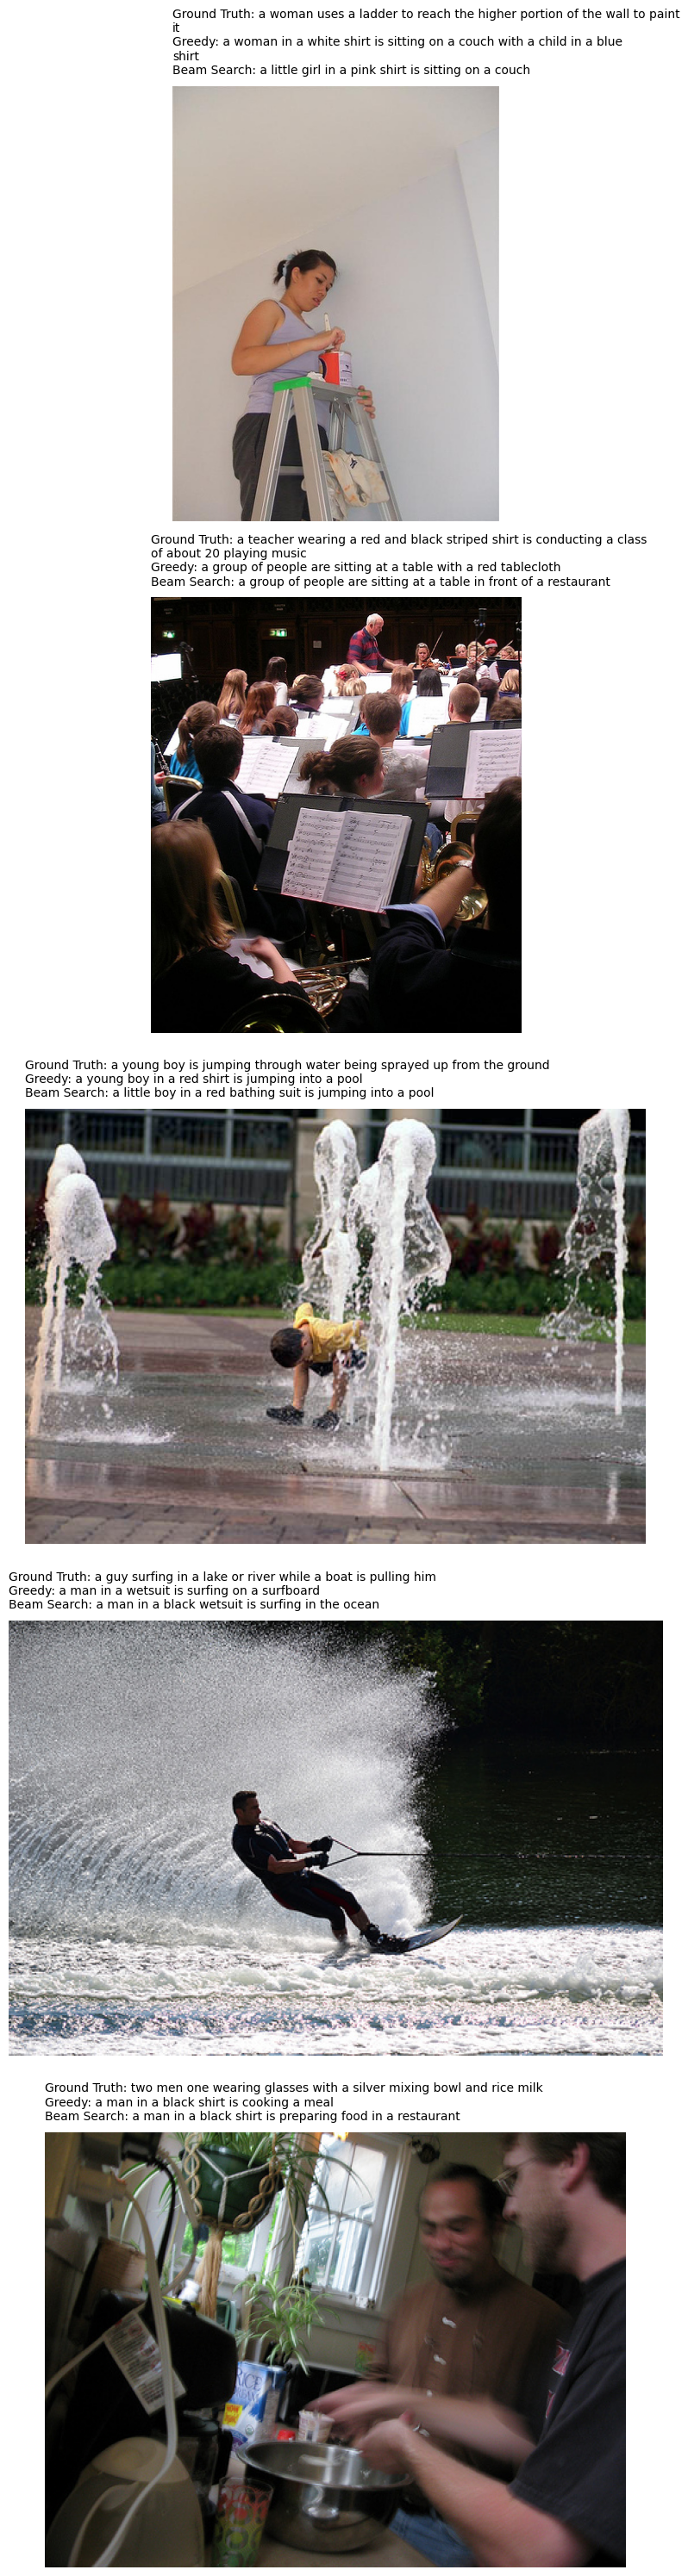

In [ ]:
"""
DELIVERABLE: Caption Examples
Display 5 random test images with ground truth and model-generated captions.
"""

import random
import matplotlib.pyplot as plt
from PIL import Image
import os
import textwrap

# Use the image directory from Part 1
IMAGE_DIR = find_image_dir()

# Pick 5 random images from the validation set predictions
sample_images = random.sample(list(predictions.keys()), 5)

fig, axes = plt.subplots(5, 1, figsize=(10, 30))

for idx, img_name in enumerate(sample_images):
    # Load and display the actual image
    img_path = os.path.join(IMAGE_DIR, img_name)
    img = Image.open(img_path).convert('RGB')
    
    axes[idx].imshow(img)
    axes[idx].axis('off')
    
    # Get captions
    pred_greedy = greedy_search(features_dict[img_name])
    pred_beam = beam_search(features_dict[img_name], beam_width=5)
    gt_caption = ' '.join(references[img_name][0])
    
    # Format title
    title = (
        f"Ground Truth: {textwrap.fill(gt_caption, 70)}\n"
        f"Greedy: {textwrap.fill(' '.join(pred_greedy), 70)}\n"
        f"Beam Search: {textwrap.fill(' '.join(pred_beam), 70)}"
    )
    axes[idx].set_title(title, fontsize=10, loc='left', pad=10)

plt.tight_layout()
plt.show()

In [ ]:
"""
MODEL SAVING FOR GRADIO DEPLOYMENT 
"""

import torch
import json

print("="*60)
print("SAVING MODEL FOR GRADIO DEPLOYMENT")
print("="*60)

# -----------------------------------------------------------------------------
# 1. SAVE ENCODER & DECODER WEIGHTS SEPARATELY
# -----------------------------------------------------------------------------
torch.save(encoder.state_dict(), 'encoder.pth')
torch.save(decoder.state_dict(), 'decoder.pth')
print("Encoder weights saved to: encoder.pth")
print("Decoder weights saved to: decoder.pth")

# 2. SAVE COMBINED CHECKPOINT TOO
MODEL_SAVE_PATH = 'caption_model.pth'

checkpoint = {
    'encoder_state_dict': encoder.state_dict(),
    'decoder_state_dict': decoder.state_dict(),
    'vocab_size': len(word2idx),
    'embed_size': EMBED_SIZE,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS
}

torch.save(checkpoint, MODEL_SAVE_PATH)
print(f"Combined model saved to: {MODEL_SAVE_PATH}")

# -----------------------------------------------------------------------------
# 3. SAVE MODEL CONFIGURATION
# -----------------------------------------------------------------------------
CONFIG_PATH = 'model_config.json'

config = {
    'embed_size': EMBED_SIZE,
    'hidden_size': HIDDEN_SIZE,
    'vocab_size': len(word2idx),
    'feature_size': 2048,
    'max_length': MAX_SEQ_LEN,
    'num_layers': NUM_LAYERS,
    'special_tokens': {
        'start_token': '<start>',
        'end_token': '<end>',
        'pad_token': '<pad>',
        'unk_token': '<unk>'
    },
    'resnet_model': 'resnet50',
    'image_size': [224, 224],
    'normalization': {
        'mean': [0.485, 0.456, 0.406],
        'std': [0.229, 0.224, 0.225]
    }
}

with open(CONFIG_PATH, 'w') as f:
    json.dump(config, f, indent=2)
print(f"Model configuration saved to: {CONFIG_PATH}")

print("\n" + "="*60)
print("FILES SAVED FOR DEPLOYMENT:")
print("="*60)
print(f"  1. {MODEL_SAVE_PATH}  (combined checkpoint)")
print(f"  2. encoder.pth       (encoder weights)")
print(f"  3. decoder.pth       (decoder weights)")
print(f"  4. {CONFIG_PATH}     (config)")
print(f"  5. flickr30k_vocab.pkl (vocabulary)")
print("="*60)

SAVING MODEL FOR GRADIO DEPLOYMENT
Encoder weights saved to: encoder.pth
Decoder weights saved to: decoder.pth
Combined model saved to: caption_model.pth
Model configuration saved to: model_config.json

FILES SAVED FOR DEPLOYMENT:
  1. caption_model.pth  (combined checkpoint)
  2. encoder.pth       (encoder weights)
  3. decoder.pth       (decoder weights)
  4. model_config.json     (config)
  5. flickr30k_vocab.pkl (vocabulary)


# App Deployment (Gradio)
A Gradio app that allows users to upload images and generates captions using both Greedy Search and Beam Search.

In [ ]:
"""
GRADIO APP FOR IMAGE CAPTIONING

This app loads the trained Encoder-Decoder model and allows users to:
1. Upload any image
2. Get captions generated via Greedy Search and Beam Search
"""

import gradio as gr
import torch
import torch.nn as nn
import pickle
import json
from torchvision import models, transforms
from PIL import Image

# -----------------------------
# LOAD MODEL CONFIG & VOCAB
# -----------------------------
with open('model_config.json', 'r') as f:
    config = json.load(f)

with open('flickr30k_vocab.pkl', 'rb') as f:
    vocab_data = pickle.load(f)

app_word2idx = vocab_data['word2idx']
app_idx2word = vocab_data['idx2word']
app_max_len = vocab_data['max_len']

APP_EMBED_SIZE = config['embed_size']
APP_HIDDEN_SIZE = config['hidden_size']
APP_VOCAB_SIZE = config['vocab_size']
APP_NUM_LAYERS = config['num_layers']
APP_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# DEFINE MODEL CLASSES (same as training)
# -----------------------------
class AppEncoder(nn.Module):
    def __init__(self, feature_size=2048, hidden_size=APP_HIDDEN_SIZE):
        super(AppEncoder, self).__init__()
        self.fc = nn.Linear(feature_size, hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, features):
        out = self.fc(features)
        out = self.relu(out)
        out = self.dropout(out)
        return out

class AppDecoder(nn.Module):
    def __init__(self, embed_size=APP_EMBED_SIZE, hidden_size=APP_HIDDEN_SIZE,
                 vocab_size=APP_VOCAB_SIZE, num_layers=APP_NUM_LAYERS):
        super(AppDecoder, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        lstm_dropout = 0.5 if num_layers > 1 else 0
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True, dropout=lstm_dropout)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(0.5)
        self.num_layers = num_layers

    def forward(self, captions, hidden, cell):
        embeddings = self.embed(captions)
        embeddings = self.dropout(embeddings)
        outputs, (hidden, cell) = self.lstm(embeddings, (hidden, cell))
        logits = self.fc(outputs)
        return logits, hidden, cell

    def init_hidden_state(self, encoder_out):
        hidden = encoder_out.unsqueeze(0).repeat(self.num_layers, 1, 1)
        cell = torch.zeros_like(hidden)
        return hidden, cell

# -----------------------------
# LOAD TRAINED WEIGHTS
# -----------------------------
checkpoint = torch.save  # just a reference
checkpoint = torch.load('caption_model.pth', map_location=APP_DEVICE)

app_encoder = AppEncoder().to(APP_DEVICE)
app_decoder = AppDecoder().to(APP_DEVICE)

app_encoder.load_state_dict(checkpoint['encoder_state_dict'])
app_decoder.load_state_dict(checkpoint['decoder_state_dict'])
app_encoder.eval()
app_decoder.eval()

# -----------------------------
# LOAD RESNET50 FOR FEATURE EXTRACTION
# -----------------------------
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
resnet = nn.Sequential(*list(resnet.children())[:-1])
resnet = resnet.to(APP_DEVICE)
resnet.eval()

app_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=config['normalization']['mean'],
        std=config['normalization']['std']
    )
])

# -----------------------------
# INFERENCE FUNCTIONS
# -----------------------------
def extract_features(image):
    """Extract 2048-dim feature vector from an image using ResNet50."""
    img_tensor = app_transform(image).unsqueeze(0).to(APP_DEVICE)
    with torch.no_grad():
        features = resnet(img_tensor).view(1, -1)
    return features

def app_greedy_search(features, max_len=50):
    """Greedy search caption generation."""
    with torch.no_grad():
        encoder_out = app_encoder(features)
        hidden, cell = app_decoder.init_hidden_state(encoder_out)

        caption = [app_word2idx["<start>"]]
        for _ in range(max_len):
            input_tensor = torch.tensor([caption[-1]], dtype=torch.long).unsqueeze(0).to(APP_DEVICE)
            logits, hidden, cell = app_decoder(input_tensor, hidden, cell)
            next_word = logits.argmax(2).item()
            if next_word == app_word2idx["<end>"]:
                break
            caption.append(next_word)
    
    words = [app_idx2word[idx] for idx in caption[1:]]
    return ' '.join(words)

def app_beam_search(features, beam_width=5, max_len=50):
    """Beam search caption generation with length normalization."""
    with torch.no_grad():
        encoder_out = app_encoder(features)
        hidden, cell = app_decoder.init_hidden_state(encoder_out)

        beams = [([app_word2idx["<start>"]], 0.0, hidden, cell)]
        completed = []

        for _ in range(max_len):
            candidates = []
            for seq, score, h, c in beams:
                if seq[-1] == app_word2idx["<end>"]:
                    completed.append((seq, score, h, c))
                    continue
                
                input_tensor = torch.tensor([seq[-1]], dtype=torch.long).unsqueeze(0).to(APP_DEVICE)
                logits, h_new, c_new = app_decoder(input_tensor, h, c)
                probs = torch.log_softmax(logits.squeeze(1), dim=-1)
                topk_probs, topk_idx = probs.topk(beam_width, dim=-1)

                topk_probs = topk_probs.squeeze(0)
                topk_idx = topk_idx.squeeze(0)

                for k in range(beam_width):
                    next_word = topk_idx[k].item()
                    next_score = score + topk_probs[k].item()
                    candidates.append((seq + [next_word], next_score, h_new, c_new))

            if not candidates:
                break

            candidates.sort(key=lambda x: x[1] / len(x[0]), reverse=True)
            beams = candidates[:beam_width]
            
            if all(beam[0][-1] == app_word2idx["<end>"] for beam in beams):
                completed.extend(beams)
                break

        completed.extend(beams)
        completed.sort(key=lambda x: x[1] / len(x[0]), reverse=True)
        best_seq = completed[0][0]
        
        words = [app_idx2word[idx] for idx in best_seq 
                 if idx not in (app_word2idx["<start>"], app_word2idx["<end>"])]
        return ' '.join(words)

# -----------------------------
# GRADIO INTERFACE
# -----------------------------
def generate_caption(image):
    """Main function for Gradio: takes an image and returns captions."""
    if image is None:
        return "No image uploaded.", ""
    
    # Convert to PIL if needed
    if not isinstance(image, Image.Image):
        image = Image.fromarray(image).convert('RGB')
    else:
        image = image.convert('RGB')
    
    # Extract features
    features = extract_features(image)
    
    # Generate captions
    greedy_caption = app_greedy_search(features)
    beam_caption = app_beam_search(features, beam_width=5)
    
    return greedy_caption, beam_caption

# Build Gradio app
demo = gr.Interface(
    fn=generate_caption,
    inputs=gr.Image(type="pil", label="Upload an Image"),
    outputs=[
        gr.Textbox(label="Greedy Search Caption"),
        gr.Textbox(label="Beam Search Caption")
    ],
    title="Neural Storyteller - Image Captioning",
    description="Upload an image to generate captions using a Seq2Seq model (ResNet50 Encoder + LSTM Decoder) trained on Flickr30k.",
    examples=[]
)

# Launch the app
demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://8040656e6ad4da1c7e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Created dataset file at: .gradio/flagged/dataset1.csv
